#**Importacione**

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Cargar imagenes de la carpeta

In [3]:
def loadImages():
    imgs = []
    for i in range(0, 10):
        imgs.append(cv2.imread("./data-resampled/clock_1354" + ".png"))
    return imgs

In [4]:
list_img = loadImages()
list_img

[array([[[ 66,  66,  66],
         [ 72,  72,  72],
         [ 69,  69,  69],
         ...,
         [114, 114, 114],
         [112, 112, 112],
         [128, 128, 128]],
 
        [[ 53,  53,  53],
         [ 63,  63,  63],
         [ 64,  64,  64],
         ...,
         [106, 106, 106],
         [104, 104, 104],
         [120, 120, 120]],
 
        [[ 65,  65,  65],
         [ 70,  70,  70],
         [ 65,  65,  65],
         ...,
         [105, 105, 105],
         [102, 102, 102],
         [118, 118, 118]],
 
        ...,
 
        [[254, 254, 254],
         [253, 253, 253],
         [253, 253, 253],
         ...,
         [150, 150, 150],
         [161, 161, 161],
         [ 98,  98,  98]],
 
        [[254, 254, 254],
         [253, 253, 253],
         [253, 253, 253],
         ...,
         [157, 157, 157],
         [164, 164, 164],
         [111, 111, 111]],
 
        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [172, 172, 172],
  

In [5]:

# Convertir a escala de grises
def grayScale(list_img):
    gray_list = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in list_img]
    return gray_list

# Binarización
def binarize(gray_list):
    bin_list = [cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)[1] for img in gray_list]
    return bin_list

# Reducción de ruido (aplicar sobre binarizadas)
def denoise(bin_list):
    clean_list = [cv2.medianBlur(img, 5) for img in bin_list]
    return clean_list

def enhance_gray(gray_img):
    # 1. Ecualización adaptativa
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    gray_eq = clahe.apply(gray_img)

    # 2. Bordes normales
    edges1 = cv2.Canny(gray_eq, 50, 150)

    # 3. Bordes en imagen invertida (para agujas claras)
    inv = cv2.bitwise_not(gray_eq)
    edges2 = cv2.Canny(inv, 50, 150)

    # 4. Fusión
    edges = cv2.bitwise_or(edges1, edges2)

    return edges


# ==== USO ====
# 1) Cargar imágenes
list_img = loadImages()

# 2) Escala de grises
list_img_gray = grayScale(list_img)

# 3) Binarización
list_img_bin = binarize(list_img_gray)

# 4) Reducción de ruido
list_img_clean = denoise(list_img_bin)

list_img_edges = [enhance_gray(img) for img in list_img_gray]


print(f"Original: {len(list_img)} | Grises: {len(list_img_gray)} | Binarias: {len(list_img_bin)} | Limpias: {len(list_img_clean)} | RealceGris {len(list_img_edges)}")


Original: 10 | Grises: 10 | Binarias: 10 | Limpias: 10 | RealceGris 10


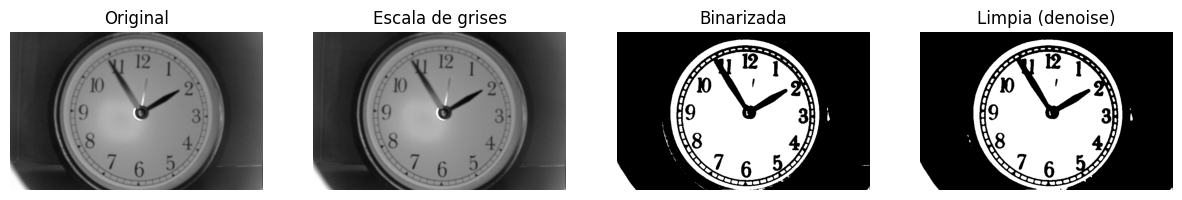

In [6]:
import matplotlib.pyplot as plt

def show_steps(idx):
    plt.figure(figsize=(15,5))

    
    plt.subplot(1,4,1)
    plt.imshow(cv2.cvtColor(list_img[idx], cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    
    plt.subplot(1,4,2)
    plt.imshow(list_img_gray[idx], cmap='gray')
    plt.title("Escala de grises")
    plt.axis("off")

    
    plt.subplot(1,4,3)
    plt.imshow(list_img_bin[idx], cmap='gray')
    plt.title("Binarizada")
    plt.axis("off")

    
    plt.subplot(1,4,4)
    plt.imshow(list_img_clean[idx], cmap='gray')
    plt.title("Limpia (denoise)")
    plt.axis("off")

  

    plt.show()


show_steps(0)


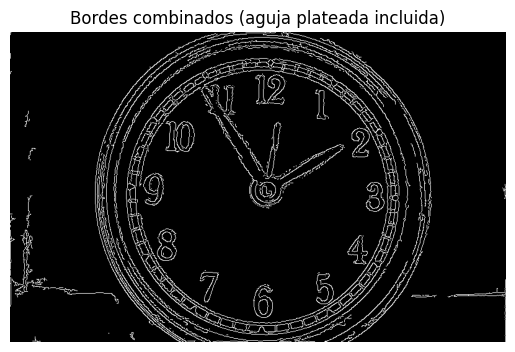

In [24]:
plt.imshow(list_img_edges[0], cmap="gray")
plt.title("Bordes combinados (aguja plateada incluida)")
plt.axis("off")
plt.show()
    



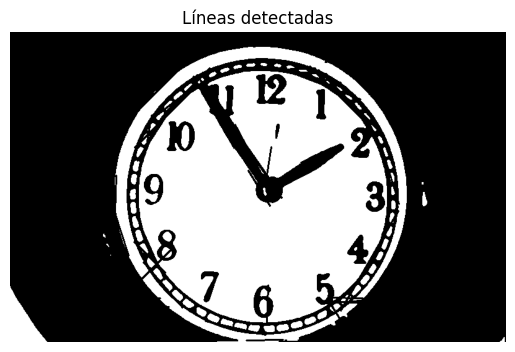

In [23]:
edges = list_img_edges[0]

lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80,
                        minLineLength=50, maxLineGap=10)

vis = list_img_clean[0].copy()
if lines is not None:
    for x1,y1,x2,y2 in lines[:,0]:
        cv2.line(vis, (x1,y1), (x2,y2), (0,0,255), 2)

plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Líneas detectadas")
plt.axis("off")
plt.show()


In [14]:

import cv2                
import numpy as np        
import math               
from itertools import permutations  
import matplotlib.pyplot as plt     


In [15]:
#Funciones de ángulos y utilidades
def ang_norm(a: float) -> float:
    a = a % 360.0
    return a if a >= 0 else a + 360.0

def ang_diff(a: float, b: float) -> float:
    d = abs((a - b) % 360.0)
    return min(d, 360.0 - d)


In [16]:
#Preprocesamiento y detección de bordes
def enhance_edges(gray: np.ndarray):
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    g = clahe.apply(gray)
    inv = cv2.bitwise_not(g)
    e1 = cv2.Canny(g,   25,  90)
    e2 = cv2.Canny(g,   50, 150)
    e3 = cv2.Canny(inv, 25,  90)
    e4 = cv2.Canny(inv, 50, 150)
    edges = cv2.bitwise_or(cv2.bitwise_or(e1, e2), cv2.bitwise_or(e3, e4))
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)
    return edges, g


In [17]:
#Detección del reloj (centro y círculo)
def detect_clock_center(gray_eq: np.ndarray):
    h, w = gray_eq.shape[:2]
    min_r = int(min(h, w) * 0.25)
    max_r = int(min(h, w) * 0.60)

    circles = cv2.HoughCircles(
        gray_eq, cv2.HOUGH_GRADIENT,
        dp=1.2, minDist=min(h, w)//4,
        param1=120, param2=40,
        minRadius=min_r, maxRadius=max_r
    )

    if circles is not None:
        x, y, r = np.round(circles[0, 0]).astype(int)
        return (x, y), r

    cx, cy = w // 2, h // 2
    r = int(min(h, w) * 0.45)
    return (cx, cy), r

def circular_mask(shape, center, r_min, r_max):
    H, W = shape
    cx, cy = center
    Y, X = np.ogrid[:H, :W]
    R = np.sqrt((X - cx)**2 + (Y - cy)**2)
    return ((R >= r_min) & (R <= r_max)).astype(np.uint8) * 255


In [18]:
#Rayos y picos (detección de manecillas)
def ray_votes(edges, center, r_in, r_out, step_deg=0.5):
    H, W = edges.shape
    cx, cy = center
    angles = np.arange(0.0, 360.0, step_deg, dtype=np.float32)
    scores = np.zeros_like(angles, dtype=np.float32)
    rs = np.linspace(r_in, r_out, int(max(1, r_out - r_in)) + 1, dtype=np.float32)
    
    for i, a in enumerate(angles):
        ar = np.deg2rad(a)
        xs = cx + rs * np.sin(ar)
        ys = cy - rs * np.cos(ar)
        xi = np.rint(xs).astype(np.int32)
        yi = np.rint(ys).astype(np.int32)
        mask = (xi >= 0) & (xi < W) & (yi >= 0) & (yi < H)
        if not np.any(mask):
            continue
        vals = edges[yi[mask], xi[mask]].astype(np.float32) / 255.0
        scores[i] = np.sum(vals)
    
    scores = cv2.GaussianBlur(scores.reshape(1, -1), (1, 0), sigmaX=2).ravel()
    return angles, scores

def top_peaks(angles, scores, n=3, sep_deg=12):
    idxs, sc = [], scores.copy()
    for _ in range(n * 4):
        k = int(np.argmax(sc))
        if sc[k] <= 0:
            break
        ok = True
        for j in idxs:
            if ang_diff(angles[k], angles[j]) < sep_deg:
                ok = False; break
        if ok:
            idxs.append(k)
            if len(idxs) == n:
                break
        sup = int(round(sep_deg / (angles[1] - angles[0])))
        for d in range(-sup, sup + 1):
            sc[(k + d) % len(sc)] = -1
    idxs.sort()
    return [angles[i] for i in idxs]


In [19]:
#Asignación de hora
def assign_best_time(angles, lengths):
    best = None
    for (iH, iM, iS) in permutations([0,1,2], 3):
        ah, am, asec = angles[iH], angles[iM], angles[iS]
        S = int(round(asec / 6.0)) % 60
        M = int(round(am / 6.0)) % 60
        H = int(round(ah / 30.0)) % 12
        H = 12 if H == 0 else H
        cand = (0, H, M, S, (iH, iM, iS))
        if (best is None) or (cand[0] < best[0]): best = cand
    _, H, M, S, order = best
    return H, M, S, order


In [20]:
#Visualización
def draw_clock(img, center, R, angles, lengths, order, time):
    cx, cy = center
    vis = img.copy()
    cols = [(0,0,255), (255,0,0), (0,255,0)]  # H, M, S
    H, M, S = time
    
    for col, idx in zip(cols, order):
        a = np.deg2rad(angles[idx])
        L = lengths[idx]
        x2 = int(round(cx + L * np.sin(a)))
        y2 = int(round(cy - L * np.cos(a)))
        cv2.line(vis, (cx, cy), (x2, y2), col, 3)

    cv2.circle(vis, center, 4, (0,255,255), -1)  
    cv2.circle(vis, center, R, (255,255,0), 2)   

    return vis


In [21]:
#Orquestador principal
def read_clock_time(img_bgr: np.ndarray, debug: bool = False):
    if img_bgr is None:
        raise ValueError("Imagen inválida")

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    edges, gray_eq = enhance_edges(gray)
    center, R = detect_clock_center(gray_eq)

    roi = circular_mask(edges.shape, center, 0.10 * R, 0.98 * R)
    edges = cv2.bitwise_and(edges, roi)

    aSeed, sSeed = ray_votes(edges, center, 0.18 * R, 0.60 * R, 0.5)
    peaks_seed = top_peaks(aSeed, sSeed, 3, 12)

    angles_ref, lengths = [], []
    for a0 in peaks_seed:
        a_ref, r_tip = a0, 0.95 * R
        angles_ref.append(a_ref)
        lengths.append(r_tip)

    H, M, S, order = assign_best_time(angles_ref, lengths)

    vis = draw_clock(img_bgr, center, R, angles_ref, lengths, order, (H, M, S))

    if debug:
        plt.figure(); plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(f"Hora detectada: {H}:{M:02d}:{S:02d}")
        plt.axis("off"); plt.show()

    return (H, M, S), vis

def read_clock_time_from_path(path: str, debug: bool = False):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    return read_clock_time(img, debug)


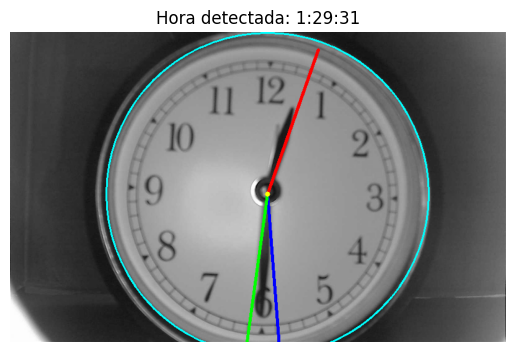

Hora detectada: 1:29:31


In [22]:
# Ruta de la imagen del reloj
PATH = "./data-resampled/clock_1230.png"

# Leer la imagen y detectar la hora
(h, m, s), vis = read_clock_time_from_path(PATH, debug=True)

print(f"Hora detectada: {h}:{m:02d}:{s:02d}")
